In [1]:
import pandas as pd

In [2]:
nyc_train = pd.read_csv("../data/processed/training_data_city_nyc-full__trainWindow_210__.csv", index_col=0)

In [3]:
nyc_train["uid"].nunique(), nyc_train["venueID"].nunique()

(1063, 27413)

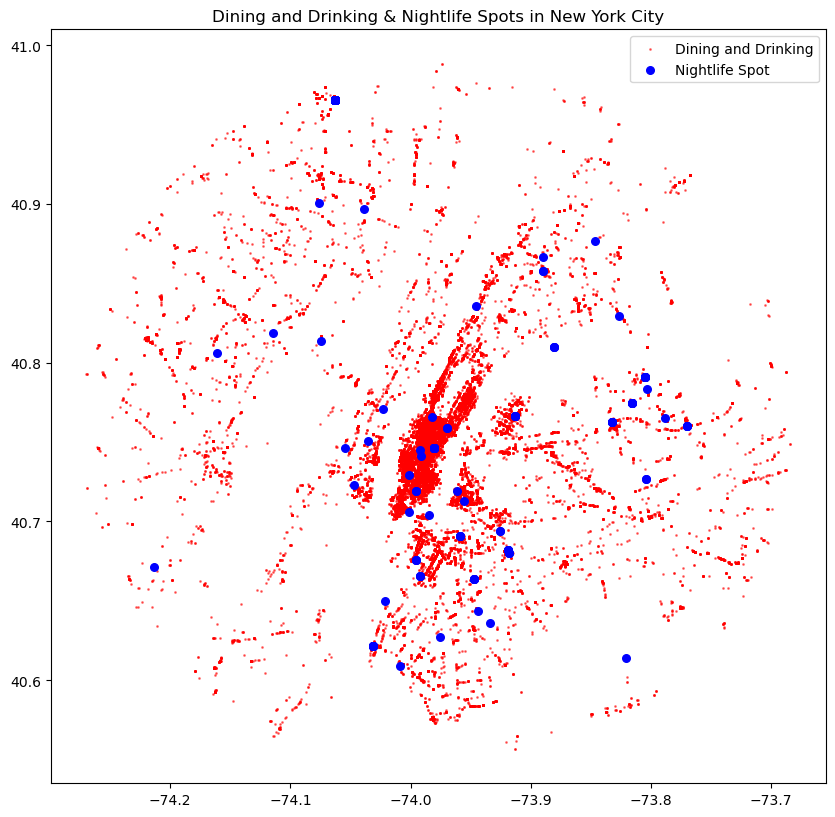

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert to GeoDataFrame
gdf_ny = gpd.GeoDataFrame(nyc_train, geometry=gpd.points_from_xy(nyc_train['lng'], nyc_train['lat']))
gdf_ny = gdf_ny.set_crs(epsg=4326)

# Filter categories
gdf_ny_dining = gdf_ny[gdf_ny['First_Category'] == "Dining and Drinking"]
gdf_ny_nightlife = gdf_ny[gdf_ny['First_Category'] == "Nightlife Spot"]

# Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot dining locations
gdf_ny_dining.plot(ax=ax, alpha=0.5, markersize=1, color='red', label='Dining and Drinking')

# Plot nightlife spots
gdf_ny_nightlife.plot(ax=ax, alpha=1, markersize=30, color='blue', label='Nightlife Spot')

# Add title and legend
plt.title("Dining and Drinking & Nightlife Spots in New York City")
plt.legend()

plt.show()


<AxesSubplot:title={'center':'NYC training set: venue visits distribution'}, xlabel='venue rank (most visited first)', ylabel='number of visits'>

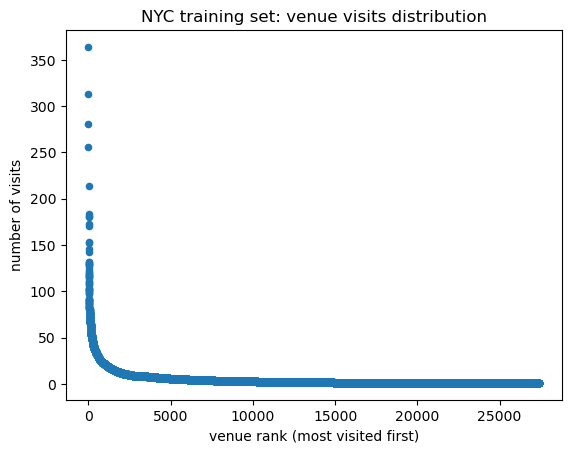

In [5]:
#plot the distribution of visits (number of times it appeaes in the training set) of the venues
#scatter plot, x=rank of the venue, y=number of visits
nyc_train.groupby("venueID").size().sort_values(ascending=False).reset_index().rename(columns={0: "visits"}).reset_index().plot.scatter(x="index", 
                                                                                                                                         y="visits", title="NYC training set: venue visits distribution", xlabel="venue rank (most visited first)", ylabel="number of visits")

<AxesSubplot:title={'center':'NYC training set: user activity distribution'}, xlabel='user rank (most active first)', ylabel='number of visits'>

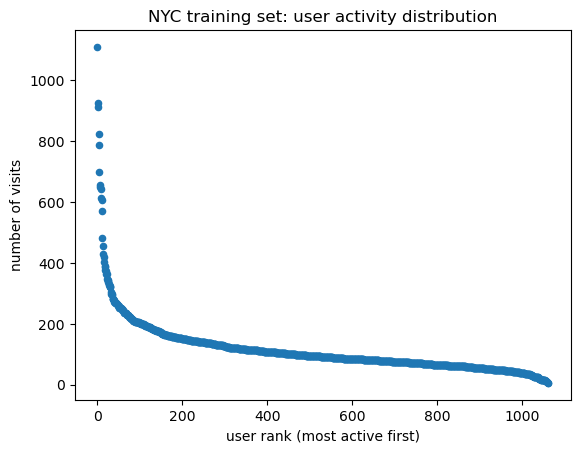

In [6]:
#plot the distribution of user activity (number of times it appeaes in the training set) of the users
#scatter plot, x=rank of the user, y=number of visits
nyc_train.groupby("uid").size().sort_values(ascending=False).reset_index().rename(columns={0: "visits"}).reset_index().plot.scatter(x="index", 
                                                                                                                  y="visits", title="NYC training set: user activity distribution", xlabel="user rank (most active first)", ylabel="number of visits")  

In [7]:
nyc_train.groupby("uid").size().sort_values(ascending=False).reset_index().rename(columns={0: "visits"}).head(50)

,uid,visits
0,185,1109
1,315,925
2,293,911
3,384,822
4,84,788
5,354,698
6,706,655
7,768,650
8,349,642
9,445,612


In [8]:
nyc_train.groupby("venueID").size().sort_values(ascending=False).reset_index().rename(columns={0: "visits"}).head(10)

,venueID,visits
0,902,364
1,2360,313
2,758,281
3,751,256
4,21907,214
5,3335,184
6,2854,181
7,16130,180
8,3668,173
9,726,170


In [9]:
tky_train = pd.read_csv("../data/processed/training_data_city_tky-full__trainWindow_210__.csv", index_col=0)
tky_train["uid"].nunique(), tky_train["venueID"].nunique()


(1051, 26423)

In [10]:
#compare starting and ending time of the two datasets. Use the "time" column in the training data
print("NYC:", nyc_train["time"].min(), nyc_train["time"].max())
print("TKY:", tky_train["time"].min(), tky_train["time"].max())

NYC: 2012-04-03 18:00:09+00:00 2012-10-30 17:59:24+00:00
TKY: 2012-04-03 19:12:07+00:00 2012-10-30 17:11:14+00:00


In [11]:
#in nyc take the n_most visited venues
n_most = 50
nyc_most_visited = nyc_train.groupby("venueID").size().nlargest(n_most).index

#in nyc_most_visited, take the ids of the venues with at least 20 visits
# n_at_least = 20
# nyc_most_visited = nyc_train.groupby("venueID").size().loc[lambda x: x >= n_at_least].index

#take the ids of the most visited venues
nyc_most_visited_ids = nyc_train[nyc_train["venueID"].isin(nyc_most_visited)]["venueID"].unique()

u_most= 50
nyc_most_active_users = nyc_train.groupby("uid").size().nlargest(u_most).index
#take the ids of the most active users
nyc_most_active_users_ids = nyc_train[nyc_train["uid"].isin(nyc_most_active_users)]["uid"].unique()

In [12]:
tky_most_visited = tky_train.groupby("venueID").size().nlargest(n_most).index
#take the ids of the most visited venues
tky_most_visited_ids = tky_train[tky_train["venueID"].isin(tky_most_visited)]["venueID"].unique()

tky_most_active_users = tky_train.groupby("uid").size().nlargest(u_most).index
#take the ids of the most active users
tky_most_active_users_ids = tky_train[tky_train["uid"].isin(tky_most_active_users)]["uid"].unique()

In [13]:
nyc_most_active_users_ids

array([  14,   84,  106,  119,  121,  178,  185,  246,  267,  280,  281,
        293,  315,  349,  354,  355,  371,  372,  384,  425,  439,  443,
        445,  448,  458,  527,  529,  646,  652,  660,  689,  706,  726,
        730,  742,  745,  768,  773,  820,  827,  872,  880,  889,  943,
        974,  990,  992, 1017, 1047, 1054])

In [14]:
algorithms = ["MultiVAE", "ItemKNN"]
seeds = [500, 501, 502, 503, 504]
version = "full"
t_window = 210
k_days = 7
topK = 20
max_simulation_days = 104
city = "nyc"
if city == "nyc":
    city_most_visited_ids = nyc_most_visited_ids
    city_most_active_users_ids = nyc_most_active_users_ids
else:
    city_most_visited_ids = tky_most_visited_ids
    city_most_active_users_ids = tky_most_active_users_ids

In [15]:
from collections import defaultdict
from pathlib import Path
from tqdm.notebook import tqdm
ps = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
new_columns = ['uid', 'lat', 'lon', 'venueID', 'venue_descr', 'time', 'city_name', 'First_Category', 'Second_Category', 'step', 'epoch', 'city', 'simulation_state']
#trajectories_dict is a dictionary in which the first level key is the probability p and the second level key is the algorithm. Then it stores the trajectories dataframe
trajectories_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
active_users = set()
for p in tqdm(ps):
    for algorithm in algorithms:
        for seed in seeds:
                
            experiment_dir = f"../data/processed/experiments/{version}/{seed}/city_{city}__train_{t_window}__step_{k_days}__max_{max_simulation_days}__topK_{topK}__alg_{algorithm}__recProb_{p}"
            merged_user_histories = pd.DataFrame()

            for user_fname in Path(experiment_dir).glob('user_histories/*.csv'):
                user_id = user_fname.stem.split('_')[0]
                user_history = pd.read_csv(user_fname, index_col=0)
                if 'simulation_state' not in user_history.columns or int(user_id) not in city_most_active_users_ids:
                    #print('skipping userid', user_id)
                    continue
                active_users.add(user_id)
                if "Unnamed: 0" in user_history.columns:
                    user_history = user_history.drop(columns=["Unnamed: 0"])
                user_history.columns = new_columns
                #keep only the rows that have simulation_state not Nan
                user_history = user_history[user_history['simulation_state'].notnull()]
                merged_user_histories = pd.concat([merged_user_histories, user_history], ignore_index=True)
                trajectories_dict[seed][p][algorithm] = merged_user_histories


  0%|          | 0/6 [00:00<?, ?it/s]

<AxesSubplot:>

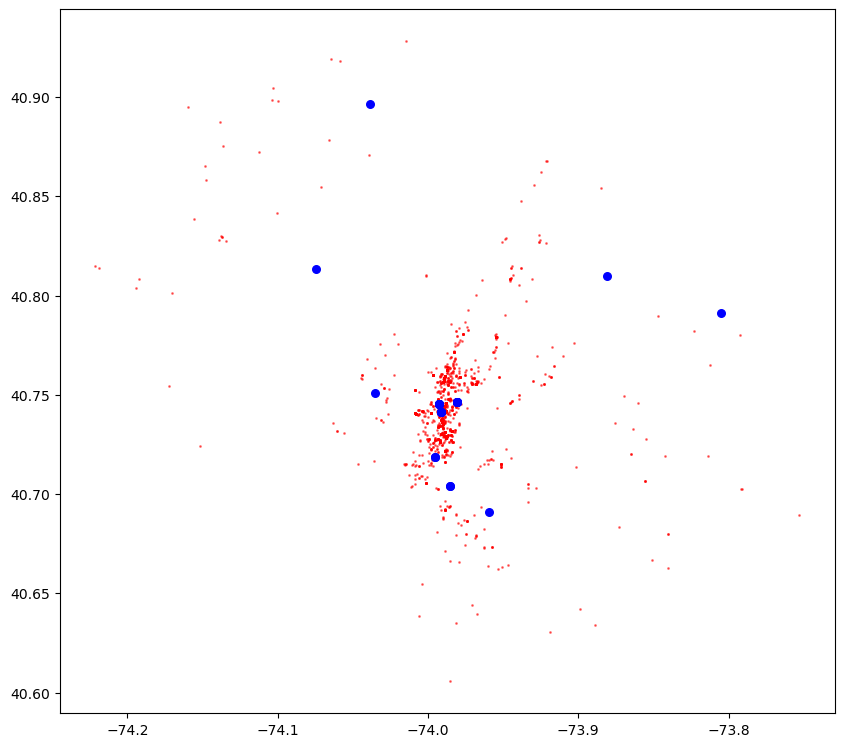

In [16]:
simulation_data = trajectories_dict[500][1]["MultiVAE"]

gdf_simulation = gpd.GeoDataFrame(simulation_data, 
    geometry=gpd.points_from_xy(simulation_data['lon'], simulation_data['lat']))
gdf_simulation = gdf_simulation.set_crs(epsg=4326)

#plot the points of the simulation of the category "Dining and Drinking" and "Nightlife Spot"
gdf_simulation_dining = gdf_simulation[gdf_simulation['First_Category'] == "Dining and Drinking"]
gdf_simulation_nightlife = gdf_simulation[gdf_simulation['First_Category'] == "Nightlife Spot"]

# Create plot
fig, ax = plt.subplots(figsize=(10, 10))
# Plot dining locations
gdf_simulation_dining.plot(ax=ax, alpha=0.5, markersize=
1, color='red', label='Dining and Drinking')
# Plot nightlife spots
gdf_simulation_nightlife.plot(ax=ax, alpha=1, markersize=30
, color='blue', label='Nightlife Spot')
# Add title and legend


In [17]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict

# Folder to store/reload the user-venue vectors
output_dir = "./user_venue_matrices"
os.makedirs(output_dir, exist_ok=True)

# Structure to populate
p_user_venue_counts = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: np.zeros(len(city_most_visited_ids), dtype=float))))

for p in tqdm(ps):
    for algorithm in algorithms:
        # Filename for the (p, algorithm) combo
        file_path = os.path.join(output_dir, f"user_venue_matrix__p_{p}__alg_{algorithm}.csv")

        # Compute from seeds
        for seed in seeds:
            df = trajectories_dict[seed][p][algorithm]
            for user_id, user_df in df.groupby('uid'):
                for i, venue_id in enumerate(city_most_visited_ids):
                    count = (user_df['venueID'] == venue_id).sum()

                    p_user_venue_counts[p][algorithm][user_id][i] += count

        # # Average across seeds
        for user_id in p_user_venue_counts[p][algorithm]:
            p_user_venue_counts[p][algorithm][user_id] /= len(seeds)

        # Convert to DataFrame and save
        df_to_save = pd.DataFrame.from_dict(
            p_user_venue_counts[p][algorithm],
            orient='index',
            columns=nyc_most_visited_ids
        )
        df_to_save.index.name = 'uid'
        df_to_save.to_csv(file_path)
        print(f"Saved to: {file_path}")

  0%|          | 0/6 [00:00<?, ?it/s]

Saved to: ./user_venue_matrices/user_venue_matrix__p_0.0__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.0__alg_ItemKNN.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.2__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.2__alg_ItemKNN.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.4__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.4__alg_ItemKNN.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.6__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.6__alg_ItemKNN.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.8__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_0.8__alg_ItemKNN.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_1.0__alg_MultiVAE.csv
Saved to: ./user_venue_matrices/user_venue_matrix__p_1.0__alg_ItemKNN.csv


In [18]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Directory where user-venue vectors are stored
input_dir = "./user_venue_matrices"

# Store cosine similarity values per (p, algorithm)
cosine_similarity_distributions = dict()

for p in ps:
    for algorithm in algorithms:
        file_path = os.path.join(input_dir, f"user_venue_matrix__p_{p}__alg_{algorithm}.csv")

        if not os.path.exists(file_path):
            print(f"[SKIP] File not found: {file_path}")
            continue

        # Load the matrix
        df = pd.read_csv(file_path, index_col='uid')

        # Drop users with all-zero vectors
        df = df[df.sum(axis=1) > 0]

        if df.shape[0] < 2:
            print(f"[SKIP] Not enough users for p={p}, algorithm={algorithm}")
            continue

        # Compute cosine similarity
        user_matrix = df.values
        sim_matrix = cosine_similarity(user_matrix)
        #check if the matrix is symmetric
        # Extract upper triangle (excluding diagonal)
        iu = np.triu_indices(sim_matrix.shape[0], k=1)
        similarity_values = sim_matrix[iu]

        # Store
        cosine_similarity_distributions[(p, algorithm)] = similarity_values
        print(f"[OK] Computed cosine similarities for p={p}, algorithm={algorithm}")


[OK] Computed cosine similarities for p=0.0, algorithm=MultiVAE
[OK] Computed cosine similarities for p=0.0, algorithm=ItemKNN
[OK] Computed cosine similarities for p=0.2, algorithm=MultiVAE
[OK] Computed cosine similarities for p=0.2, algorithm=ItemKNN
[OK] Computed cosine similarities for p=0.4, algorithm=MultiVAE
[OK] Computed cosine similarities for p=0.4, algorithm=ItemKNN
[OK] Computed cosine similarities for p=0.6, algorithm=MultiVAE
[OK] Computed cosine similarities for p=0.6, algorithm=ItemKNN
[OK] Computed cosine similarities for p=0.8, algorithm=MultiVAE
[OK] Computed cosine similarities for p=0.8, algorithm=ItemKNN
[OK] Computed cosine similarities for p=1.0, algorithm=MultiVAE
[OK] Computed cosine similarities for p=1.0, algorithm=ItemKNN


In [19]:
cosine_similarity_distributions[(1,"MultiVAE")]

array([0.        , 0.40007145, 0.59540038, 0.66641097, 0.        ,
       0.        , 0.        , 0.90460363, 0.75228365, 0.31173589,
       0.02999364, 0.39171949, 0.        , 0.        , 0.        ,
       0.29322873, 0.04141133, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.94231082, 0.64748175, 0.70098273, 0.80663756,
       0.0567048 , 0.28317725, 0.        , 0.        , 0.        ,
       0.        , 0.24618298, 0.        , 0.32824398, 0.        ,
       0.01033264, 0.        , 0.35309393, 0.        , 0.05970814,
       0.12366535, 0.        , 0.29433147, 0.        , 0.31139958,
       0.55977337, 0.42640143, 0.32541744, 0.        , 0.16705841,
       0.36037499, 0.        , 0.49522748, 0.        , 0.04329451,
       0.20100756, 0.12856487, 0.20511857, 0.        , 0.19069252,
       0.15075567, 0.        , 0.37796447, 0.30550505, 0.        ,
       0.29095719, 0.        , 0.35719738, 0.68033605, 0.13041

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

def plot_distribution_per_algorithm(distro, ps, algorithms, log = True, save_path=None, metric_name="Cos. Sim."):
    for algorithm in algorithms:
        fig, ax = plt.subplots(figsize=(9, 9), dpi=150)

        sorted_probs = sorted(ps)
        n_probs = len(sorted_probs)
        positions = np.linspace(0.1, 1, n_probs)
        inferno_colors = cm.inferno_r(positions)

        for i, p_value in enumerate(sorted_probs):
            key = (p_value, algorithm)
            if key not in distro:
                continue

            sims = distro[key]
            if len(sims) < 2:
                continue

            # Compute KDE
            kde = gaussian_kde(sims)
            #x_vals = np.linspace(0, 1, 200)
            #take the range of the data
            x_vals = np.linspace(min(sims), max(sims), 200)
            y_vals = kde(x_vals)

            # Plot
            ax.plot(x_vals, y_vals,
                    label=fr'$p = {p_value}$',
                    linewidth=3,
                    marker=None,
                    color=inferno_colors[i])

        # Aesthetics
        ax.set_title(f"{metric_name} Distribution — {algorithm}", fontsize=30, fontweight='bold', pad=20)
        ax.set_xlabel(metric_name, fontsize=26)
        ax.set_ylabel("Density", fontsize=26)
        if log:
            ax.set_yscale('log')
            ax.set_ylabel("Log Density", fontsize=26)

        ax.tick_params(axis='both', which='major', labelsize=22)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_aspect('auto')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(fontsize=20, loc='best', frameon=False)

        plt.tight_layout(pad=3)
        if save_path:
            filename = f"cosine_similarity_density__{algorithm}.pdf"
            plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
        plt.show()

def plot_violin_per_algorithm(distro, ps, algorithms, save_path=None, metric_name="Cos. Sim."):
    for algorithm in algorithms:
        fig, ax = plt.subplots(figsize=(9, 9), dpi=150)

        sorted_probs = sorted(ps)
        n_probs = len(sorted_probs)
        positions = np.arange(len(sorted_probs)) + 1  # x positions
        inferno_colors = cm.inferno_r(np.linspace(0.1, 1, n_probs))

        data = []
        labels = []

        for p_value in sorted_probs:
            key = (p_value, algorithm)
            if key not in distro:
                continue

            sims = distro[key]
            if len(sims) < 2:
                continue

            data.append(sims)
            labels.append(fr'${p_value}$')

        # Create violin plot
        parts = ax.violinplot(data,
                              showmedians=True,
                              widths=0.6,
                              showextrema=False)

        # Style violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(inferno_colors[i])
            pc.set_edgecolor('black')
            pc.set_linewidth(1)
            pc.set_alpha(1)

        # Plot median lines manually
        if 'cmedians' in parts:
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)

        # Aesthetics
        ax.set_title(f"{metric_name} Distribution — {algorithm}", fontsize=30, fontweight='bold', pad=20)
        ax.set_xlabel(r"Adoption rate $\eta$", fontsize=26)
        ax.set_ylabel(metric_name, fontsize=26)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=20)
        ax.tick_params(axis='y', which='major', labelsize=22)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_aspect('auto')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout(pad=3)
        if save_path:
            filename = f"cosine_similarity_violin__{algorithm}.pdf"
            plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
        plt.show()


def plot_boxplot_per_algorithm(distro, ps, algorithms, save_path=None, metric_name="Cos. Sim."):
    for algorithm in algorithms:
        fig, ax = plt.subplots(figsize=(9, 9), dpi=150)

        sorted_probs = sorted(ps)
        n_probs = len(sorted_probs)
        positions = np.arange(len(sorted_probs)) + 1
        inferno_colors = cm.inferno_r(np.linspace(0.1, 1, n_probs))

        data = []
        labels = []
        box_colors = []

        for i, p_value in enumerate(sorted_probs):
            key = (p_value, algorithm)
            if key not in distro:
                continue

            sims = distro[key]
            if len(sims) < 2:
                continue

            data.append(sims)
            labels.append(fr'${p_value}$')
            box_colors.append(inferno_colors[i])

        # Create boxplot without outliers
        box = ax.boxplot(data,
                         patch_artist=True,
                         labels=labels,
                         vert=True,
                         widths=0.6,
                         showfliers=True)

        # Color boxes
        for patch, color in zip(box['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)

        # Aesthetics
        ax.set_title(f"{algorithm}", fontsize=30, fontweight='bold', pad=20)
        ax.set_xlabel(r"Adoption rate $\eta$", fontsize=26)
        ax.set_ylabel(metric_name, fontsize=26)
        ax.tick_params(axis='both', which='major', labelsize=22)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_aspect('auto')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.tight_layout(pad=3)
        if save_path:
            filename = f"{metric_name.lower().replace(' ', '_')}_boxplot__{algorithm}.pdf"
            plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', dpi=300)
        plt.show()

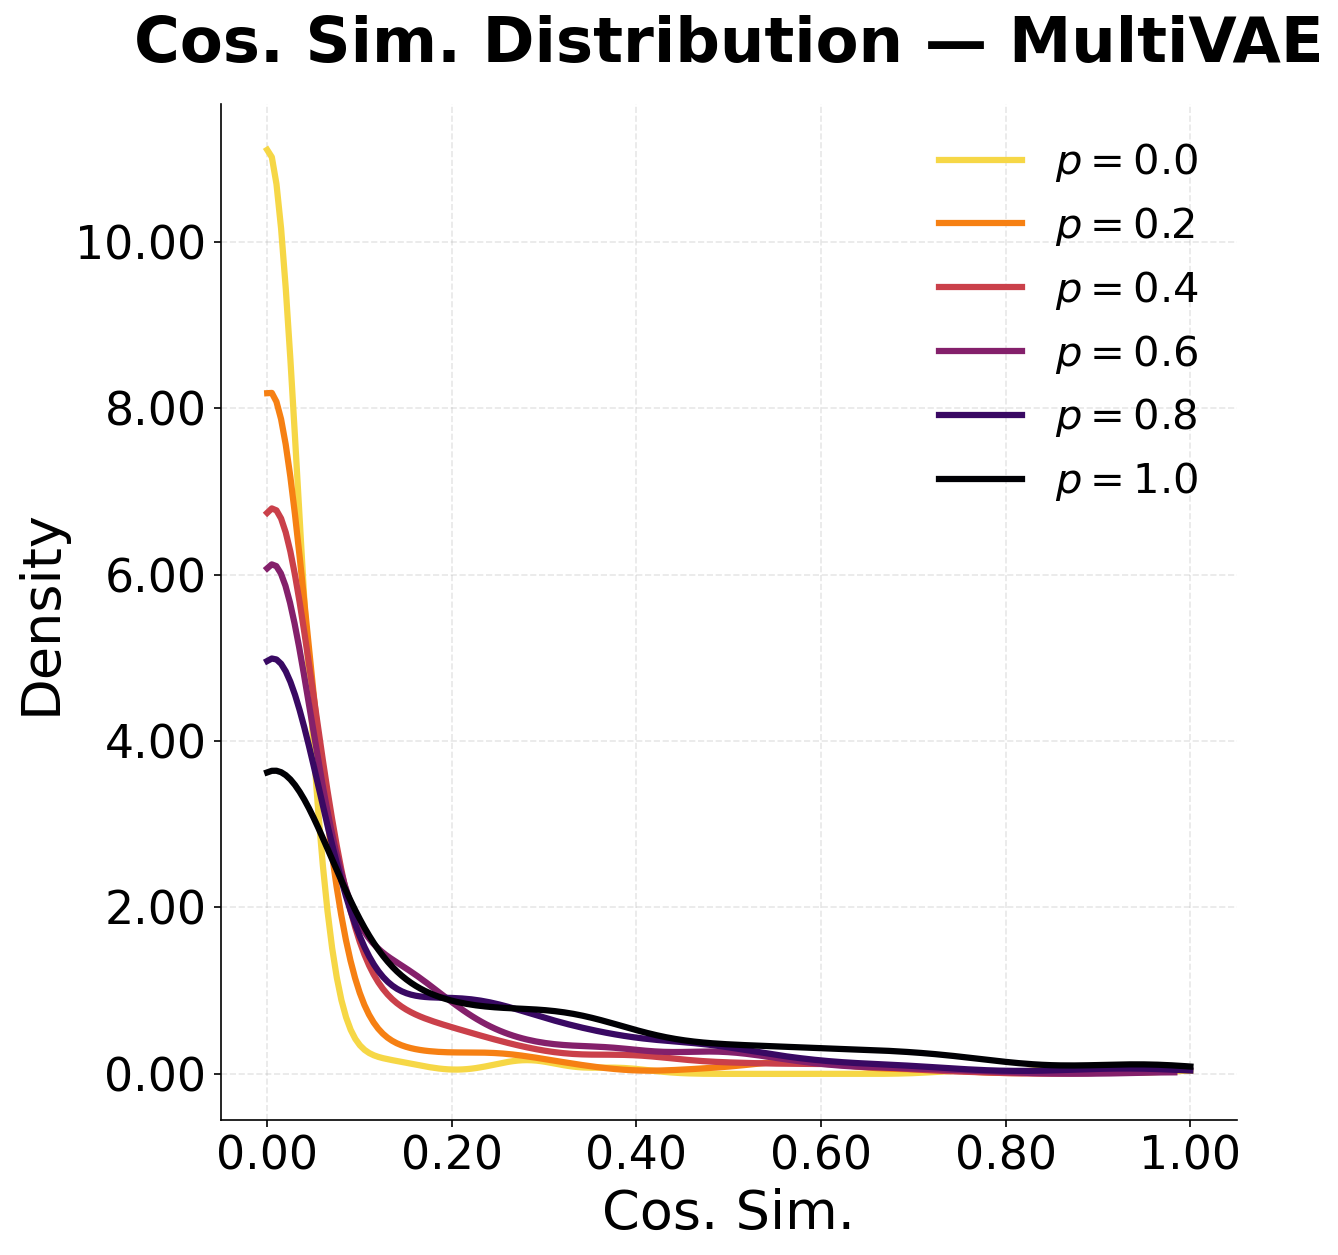

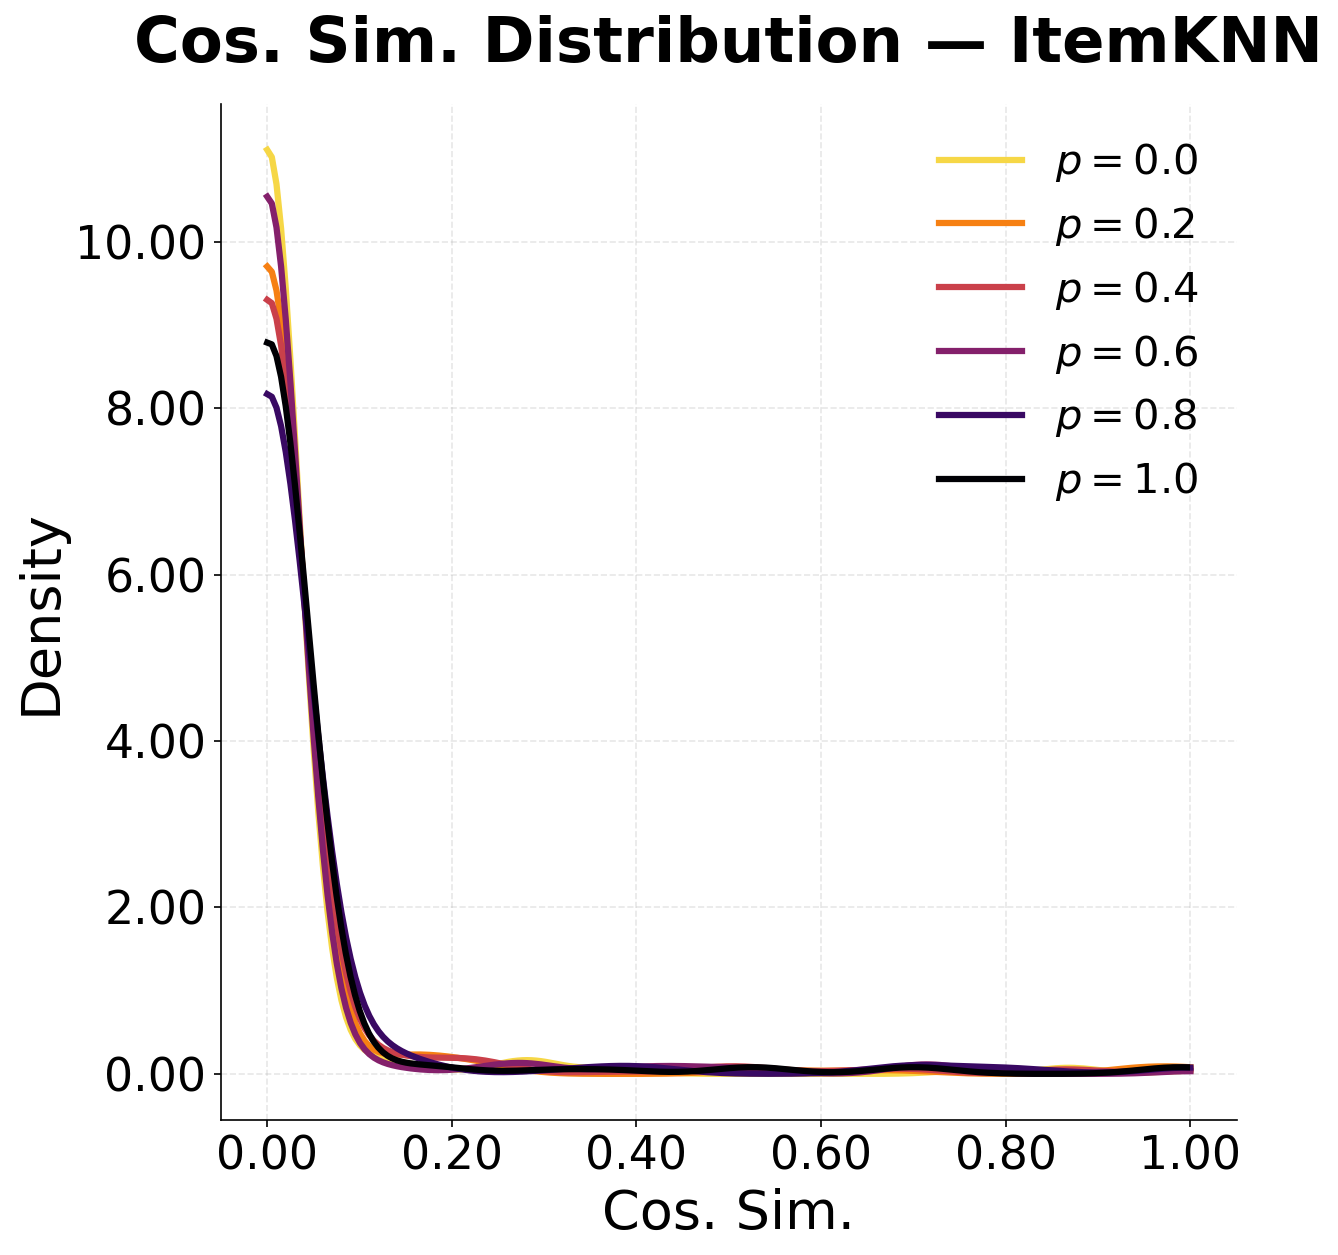

In [21]:
plot_distribution_per_algorithm(
    cosine_similarity_distributions,
    ps,
    algorithms,
    log=False,
    save_path=None
)



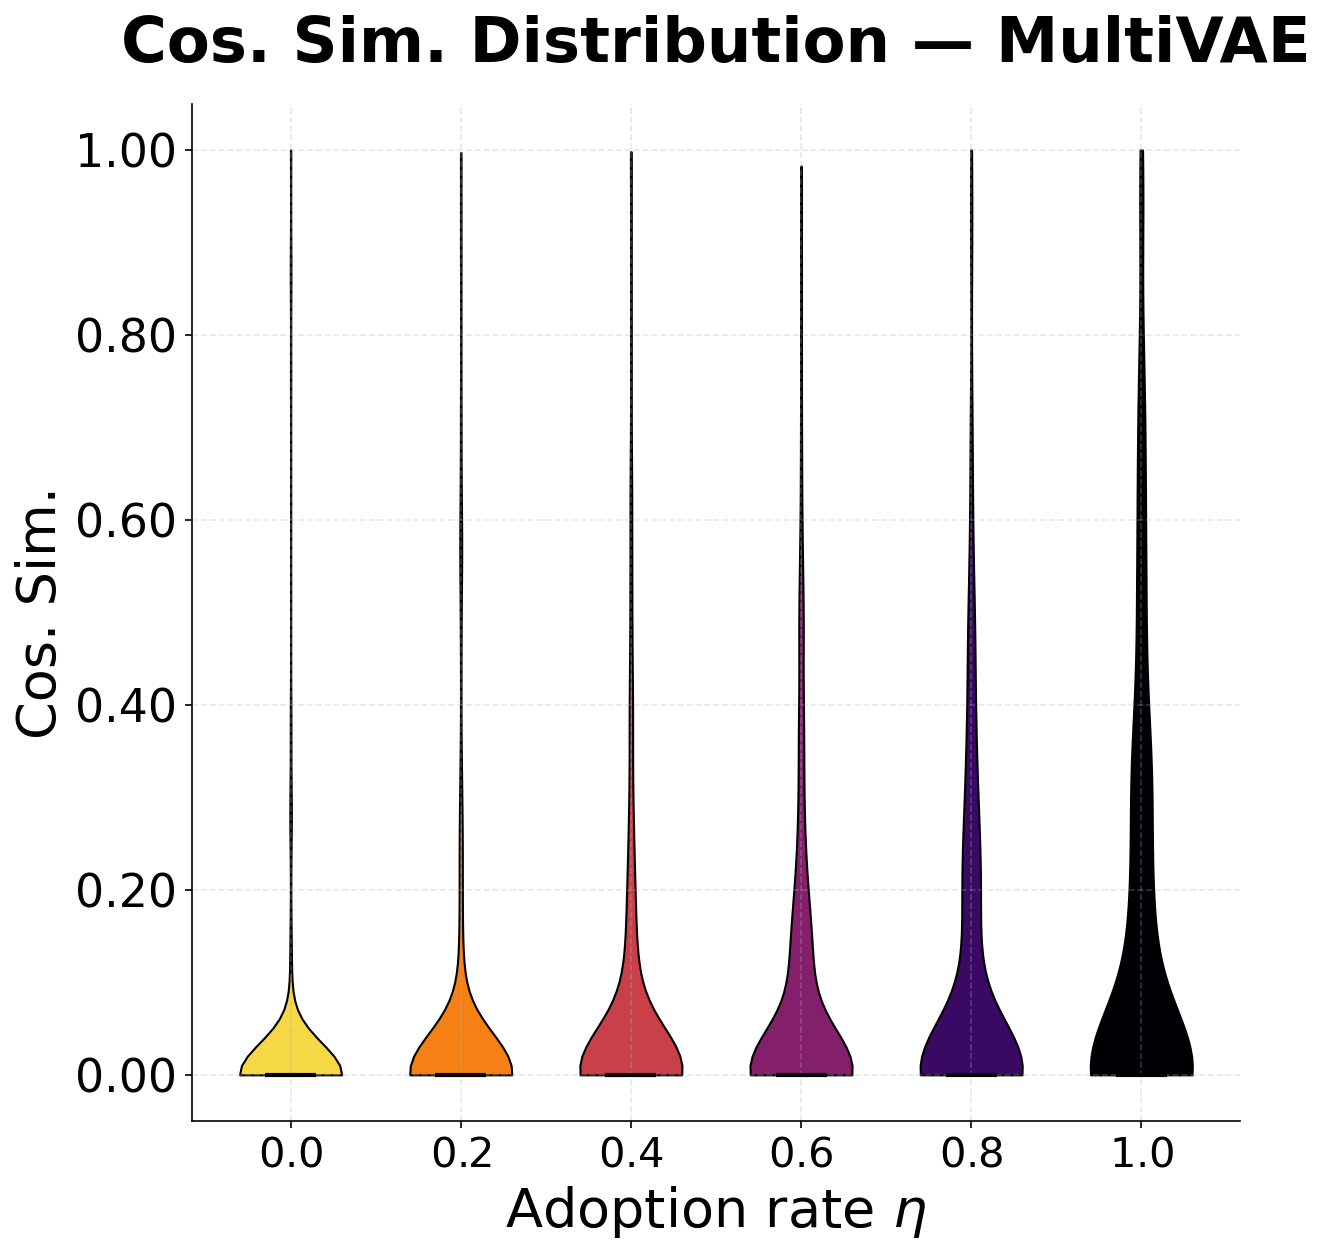

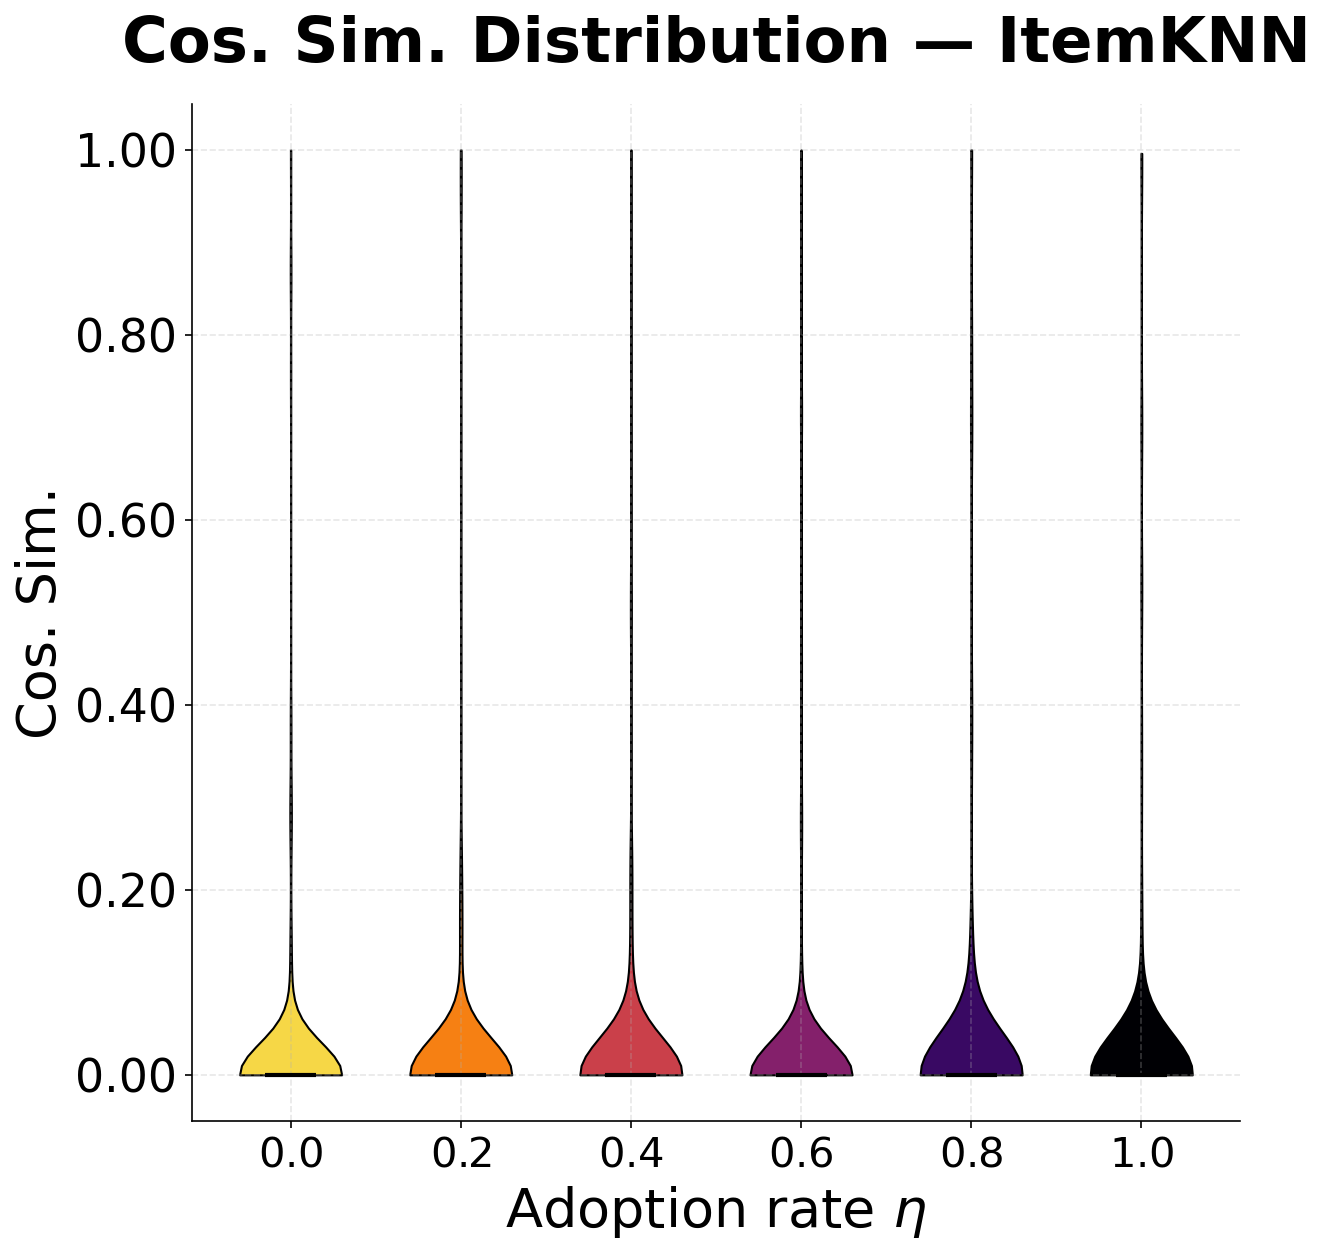

In [22]:
plot_violin_per_algorithm(
    cosine_similarity_distributions,
    ps,
    algorithms,
    save_path=None,
    metric_name="Cos. Sim."
)

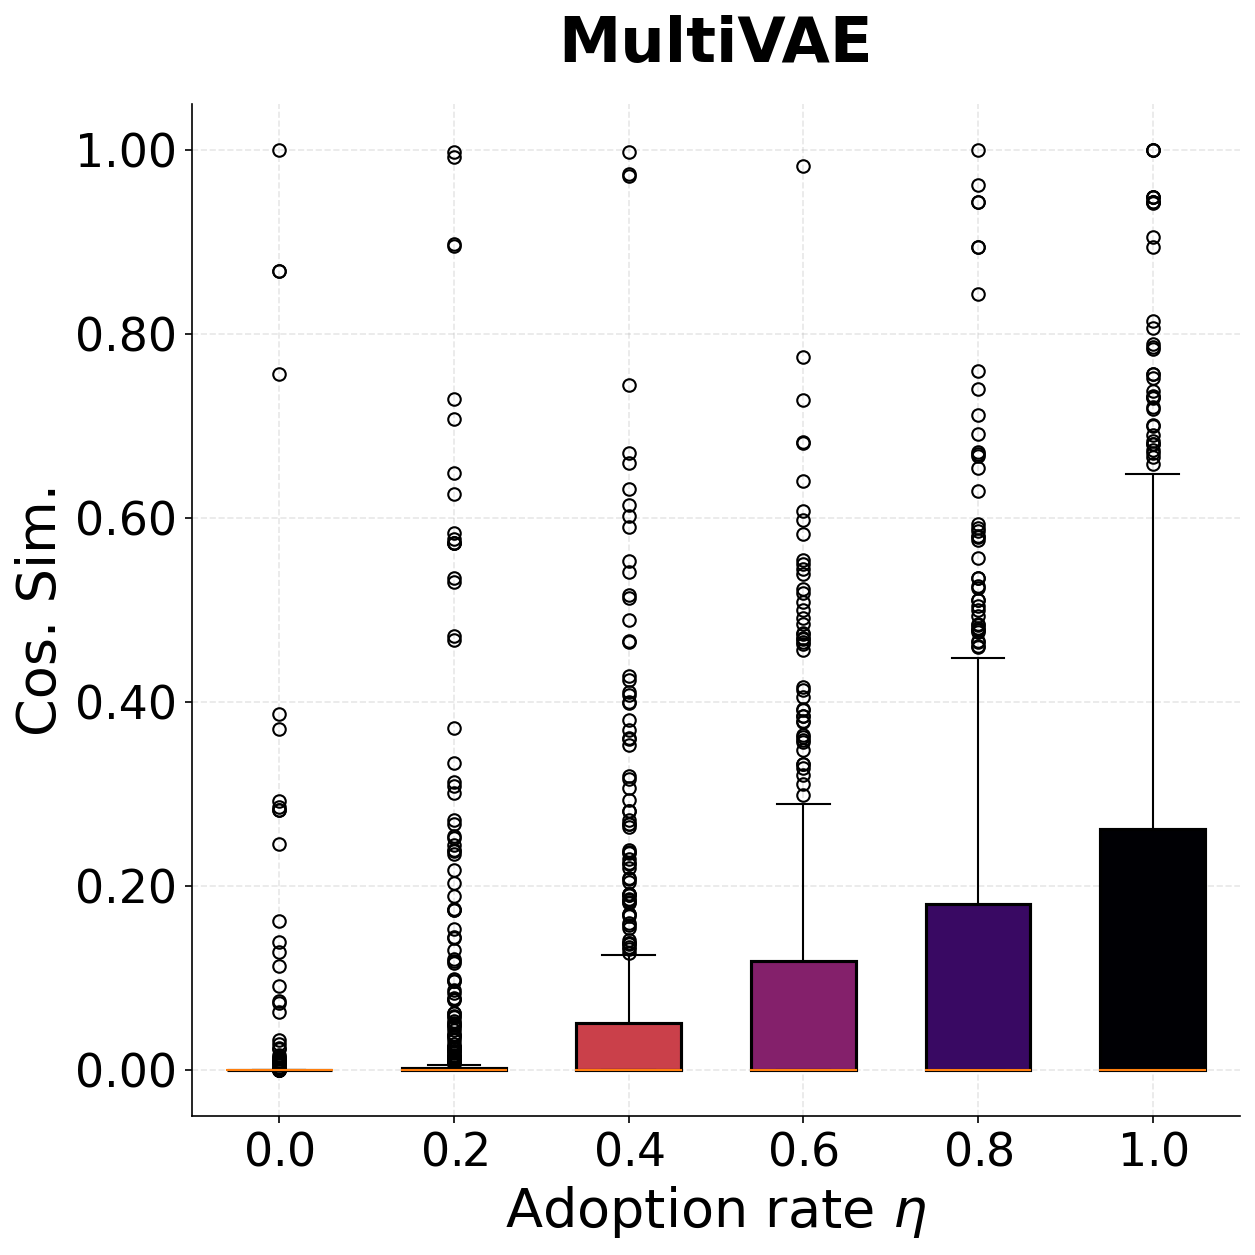

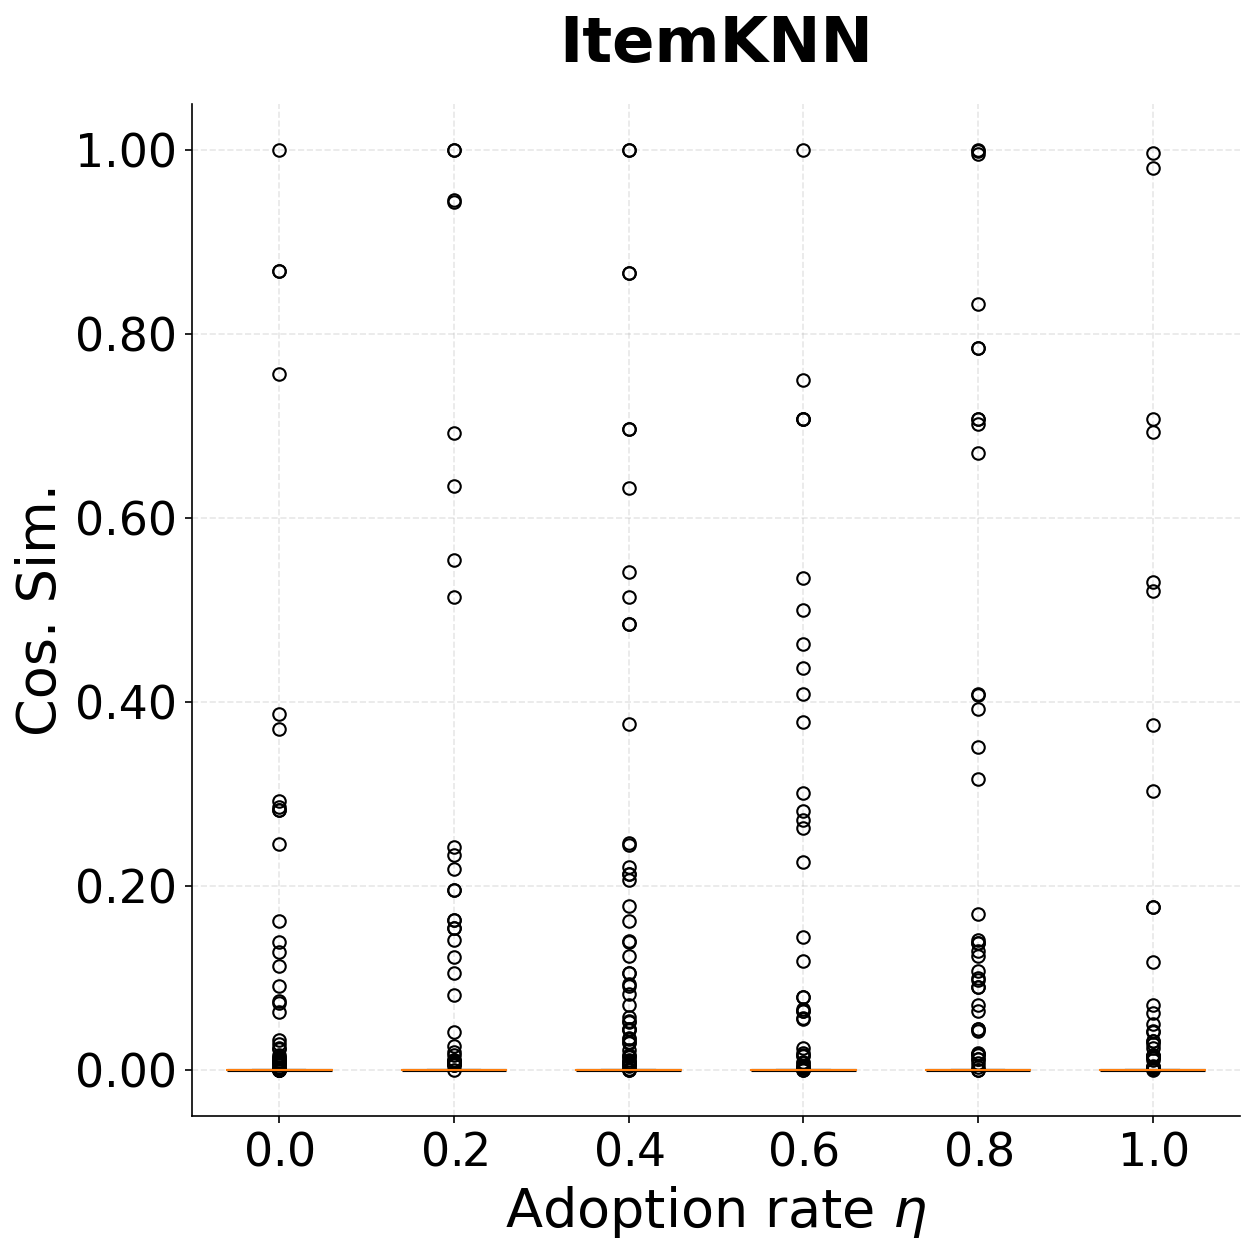

In [23]:
plot_boxplot_per_algorithm(
    cosine_similarity_distributions,
    ps,
    algorithms,
    save_path=None,
    metric_name="Cos. Sim."
)

In [24]:
import os
import numpy as np
import pandas as pd
from scipy.spatial import distance
# Directory where user-venue vectors are stored
input_dir = "./user_venue_matrices"

#store jensen-shannon distances per (p, algorithm)
jensen_shannon_distributions = dict()
for p in ps:
    for algorithm in algorithms:
        file_path = os.path.join(input_dir, f"user_venue_matrix__p_{p}__alg_{algorithm}.csv")

        if not os.path.exists(file_path):
            print(f"[SKIP] File not found: {file_path}")
            continue

        # Load the matrix
        df = pd.read_csv(file_path, index_col='uid')

        # Drop users with all-zero vectors
        df = df[df.sum(axis=1) > 0]

        if df.shape[0] < 2:
            print(f"[SKIP] Not enough users for p={p}, algorithm={algorithm}")
            continue

        # Compute Jensen-Shannon distance
        user_matrix = df.values
        js_distances = distance.pdist(user_matrix, metric='jensenshannon')

        #Subtract 1 
        js_distances = 1- js_distances 
        
        # Store
        jensen_shannon_distributions[(p, algorithm)] = js_distances
        print(f"[OK] Computed Jensen-Shannon distances for p={p}, algorithm={algorithm}")
        




[OK] Computed Jensen-Shannon distances for p=0.0, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=0.0, algorithm=ItemKNN
[OK] Computed Jensen-Shannon distances for p=0.2, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=0.2, algorithm=ItemKNN
[OK] Computed Jensen-Shannon distances for p=0.4, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=0.4, algorithm=ItemKNN
[OK] Computed Jensen-Shannon distances for p=0.6, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=0.6, algorithm=ItemKNN
[OK] Computed Jensen-Shannon distances for p=0.8, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=0.8, algorithm=ItemKNN
[OK] Computed Jensen-Shannon distances for p=1.0, algorithm=MultiVAE
[OK] Computed Jensen-Shannon distances for p=1.0, algorithm=ItemKNN


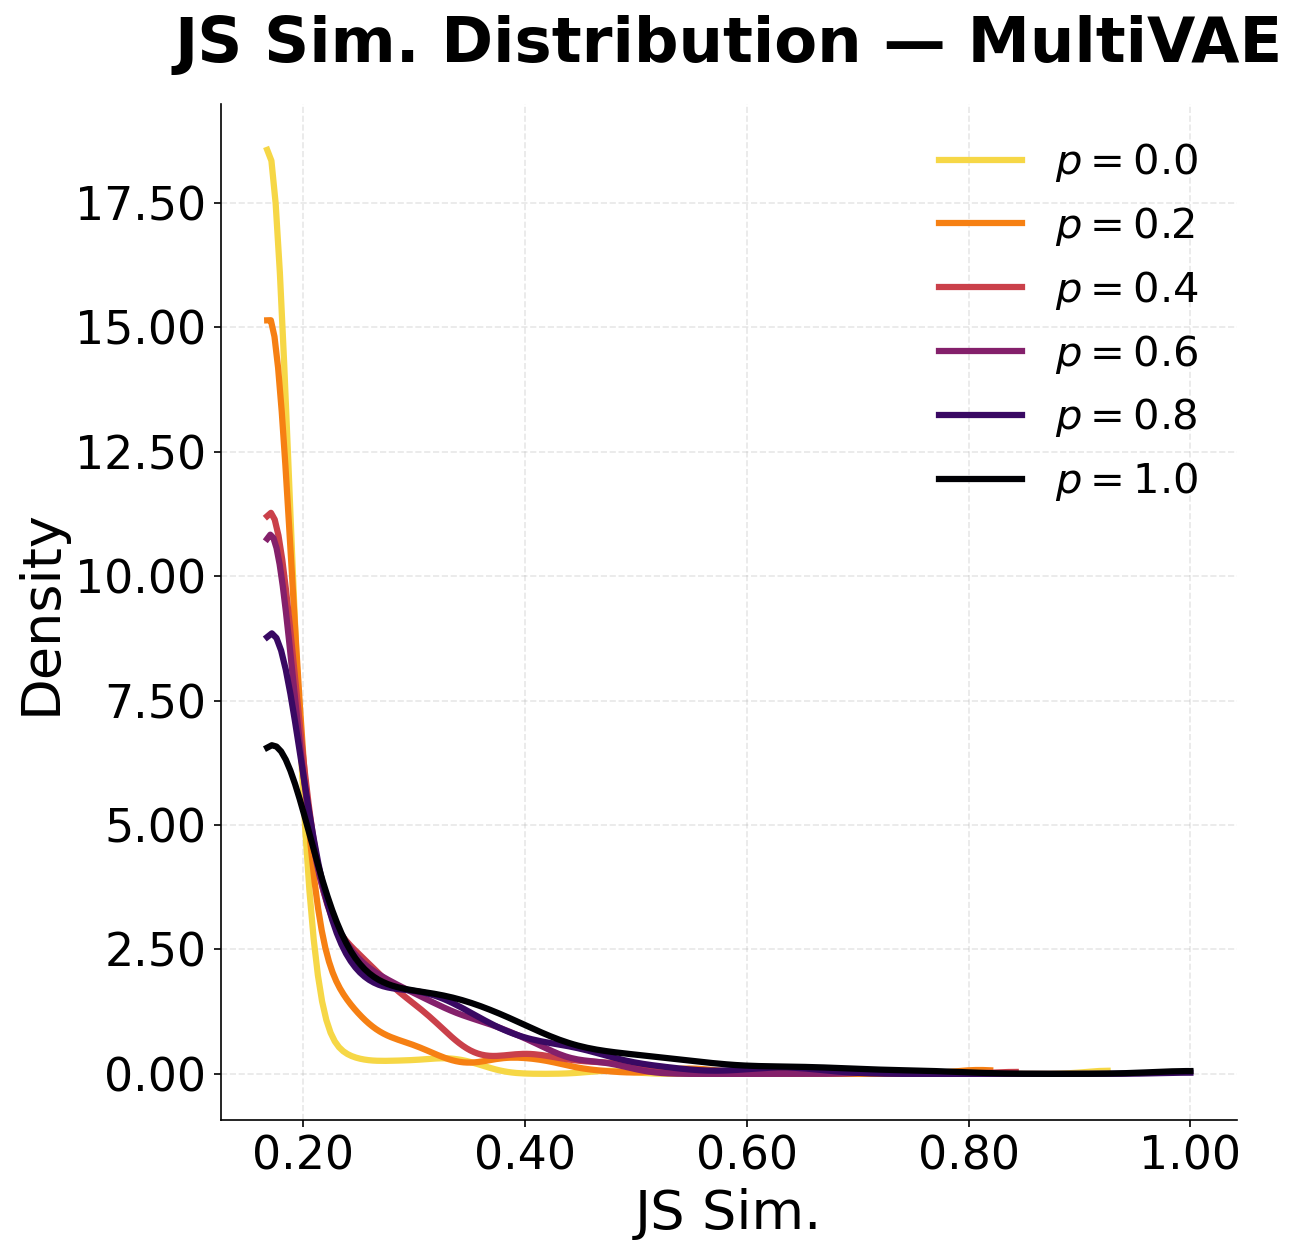

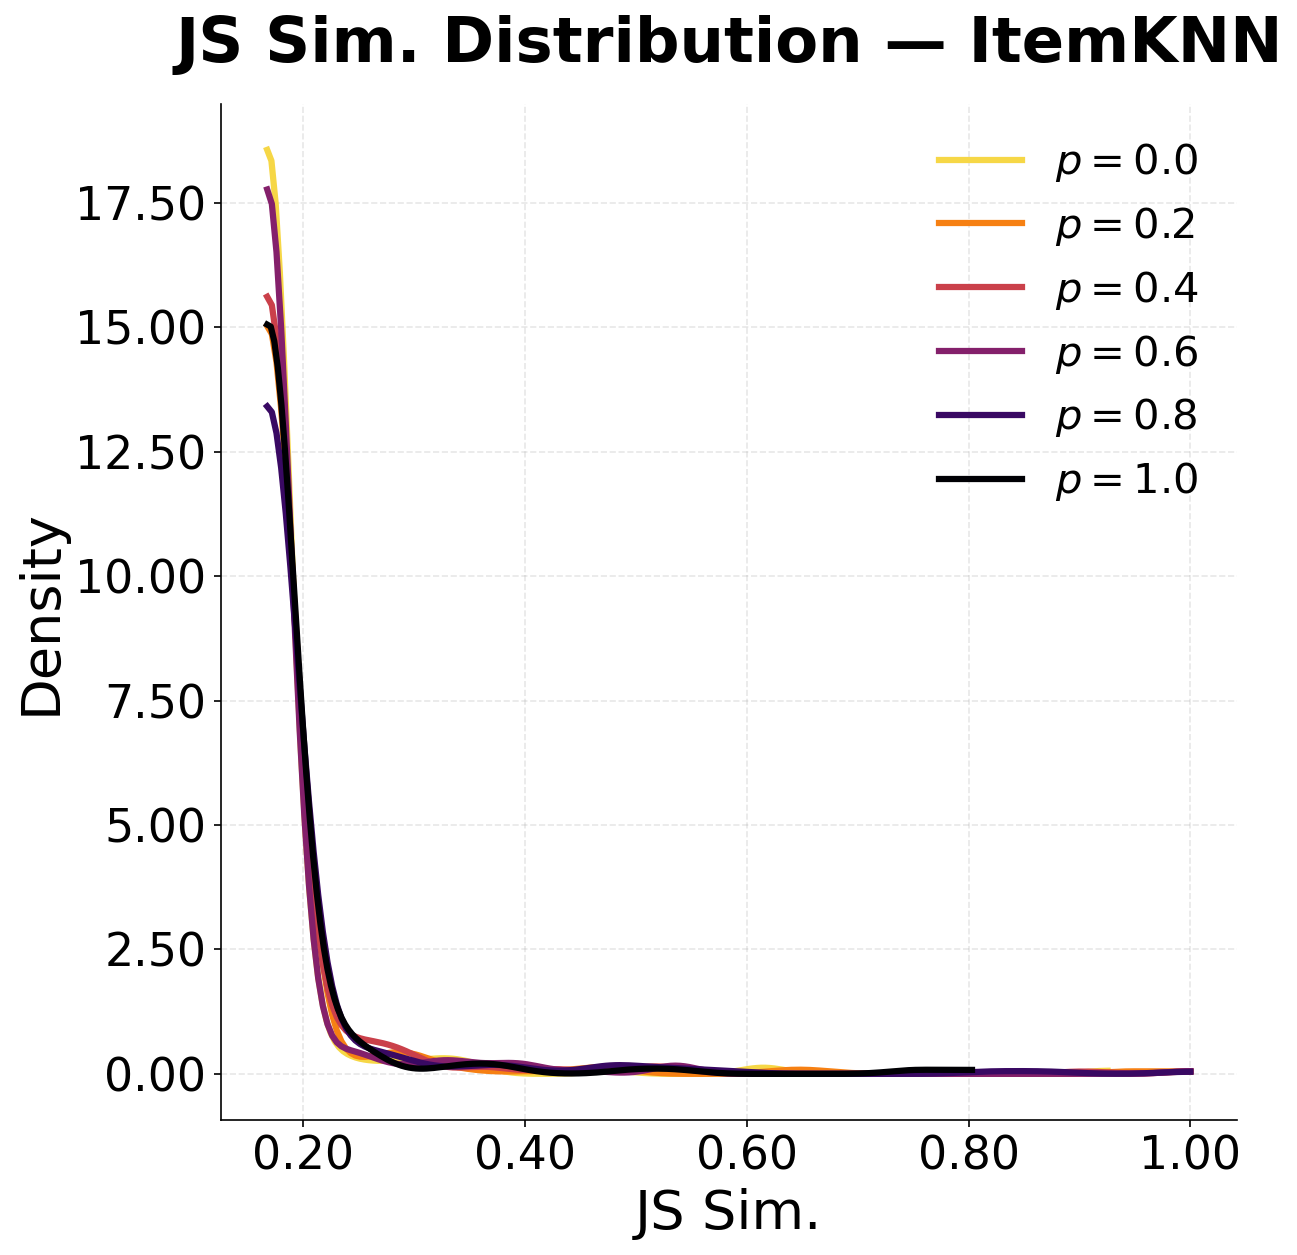

In [25]:
plot_distribution_per_algorithm(    jensen_shannon_distributions,
    ps,
    algorithms,
    log=False,
    save_path=None,
    metric_name="JS Sim."
)

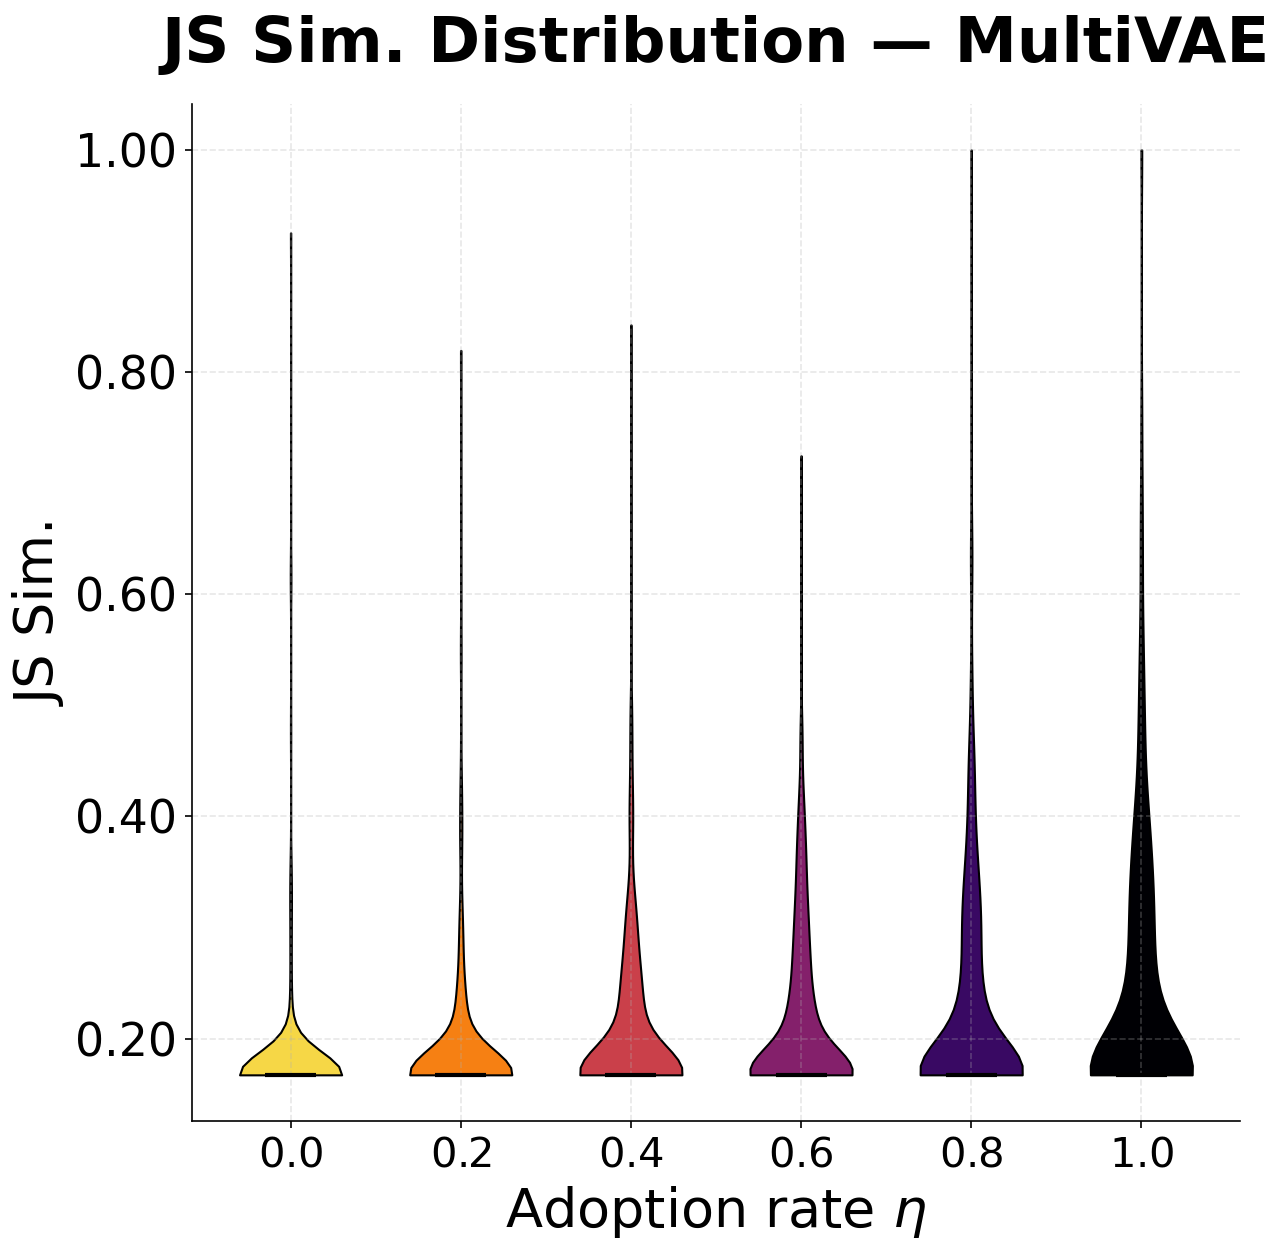

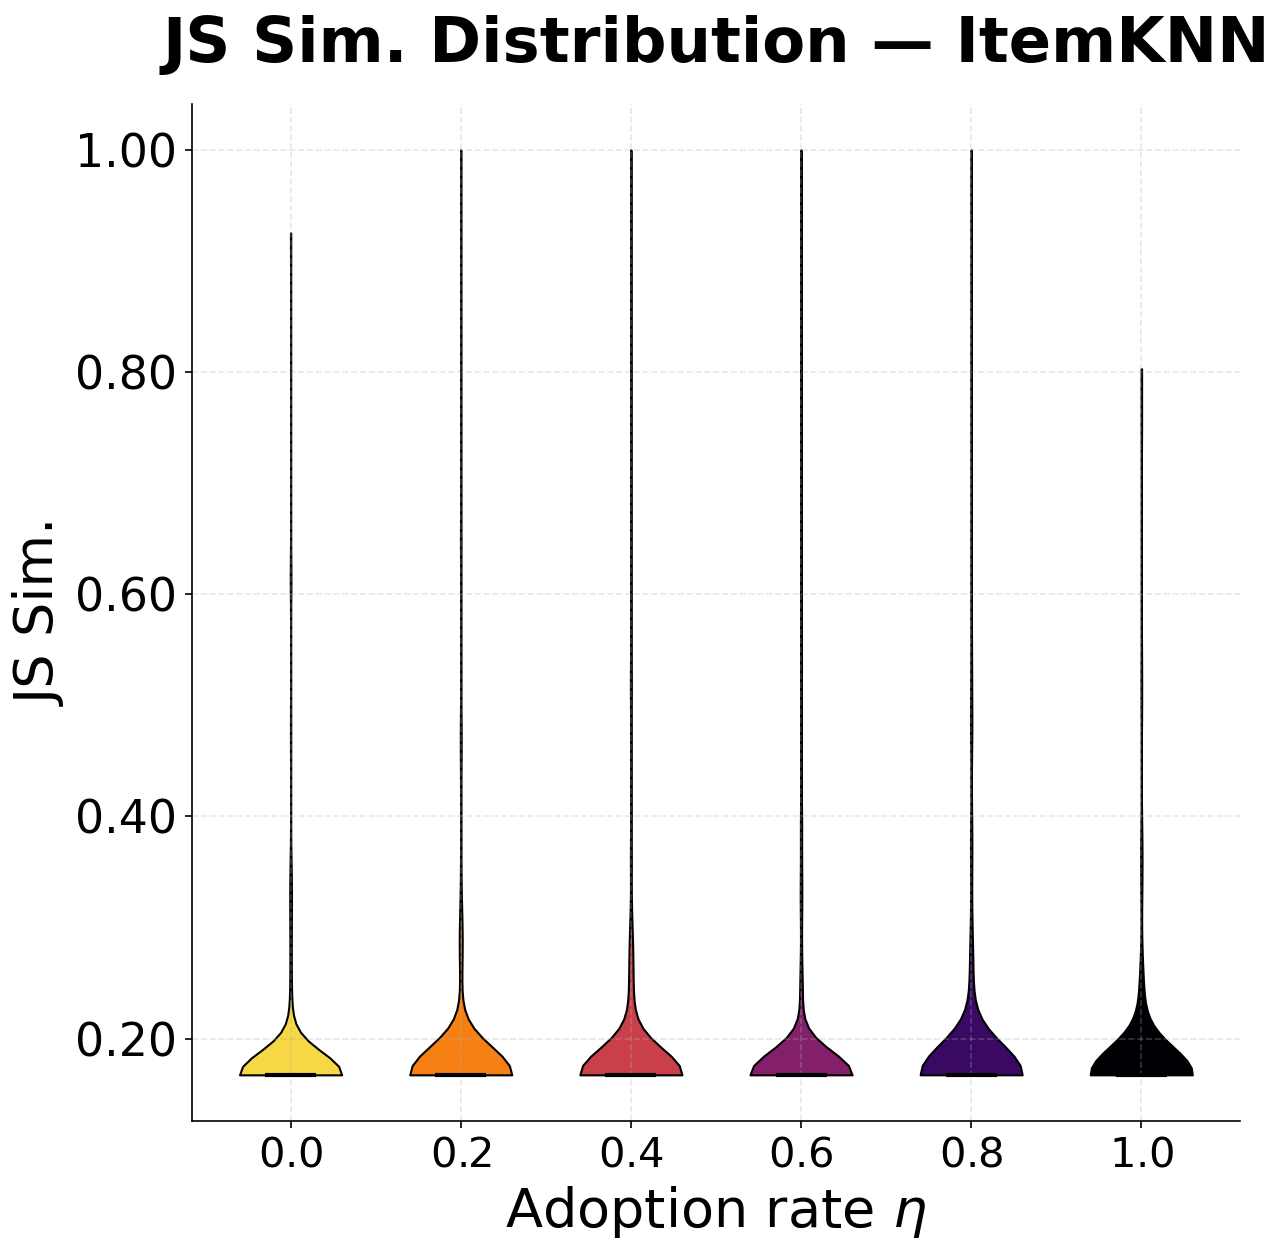

In [26]:
plot_violin_per_algorithm(jensen_shannon_distributions, ps, algorithms, save_path=None, metric_name="JS Sim.")

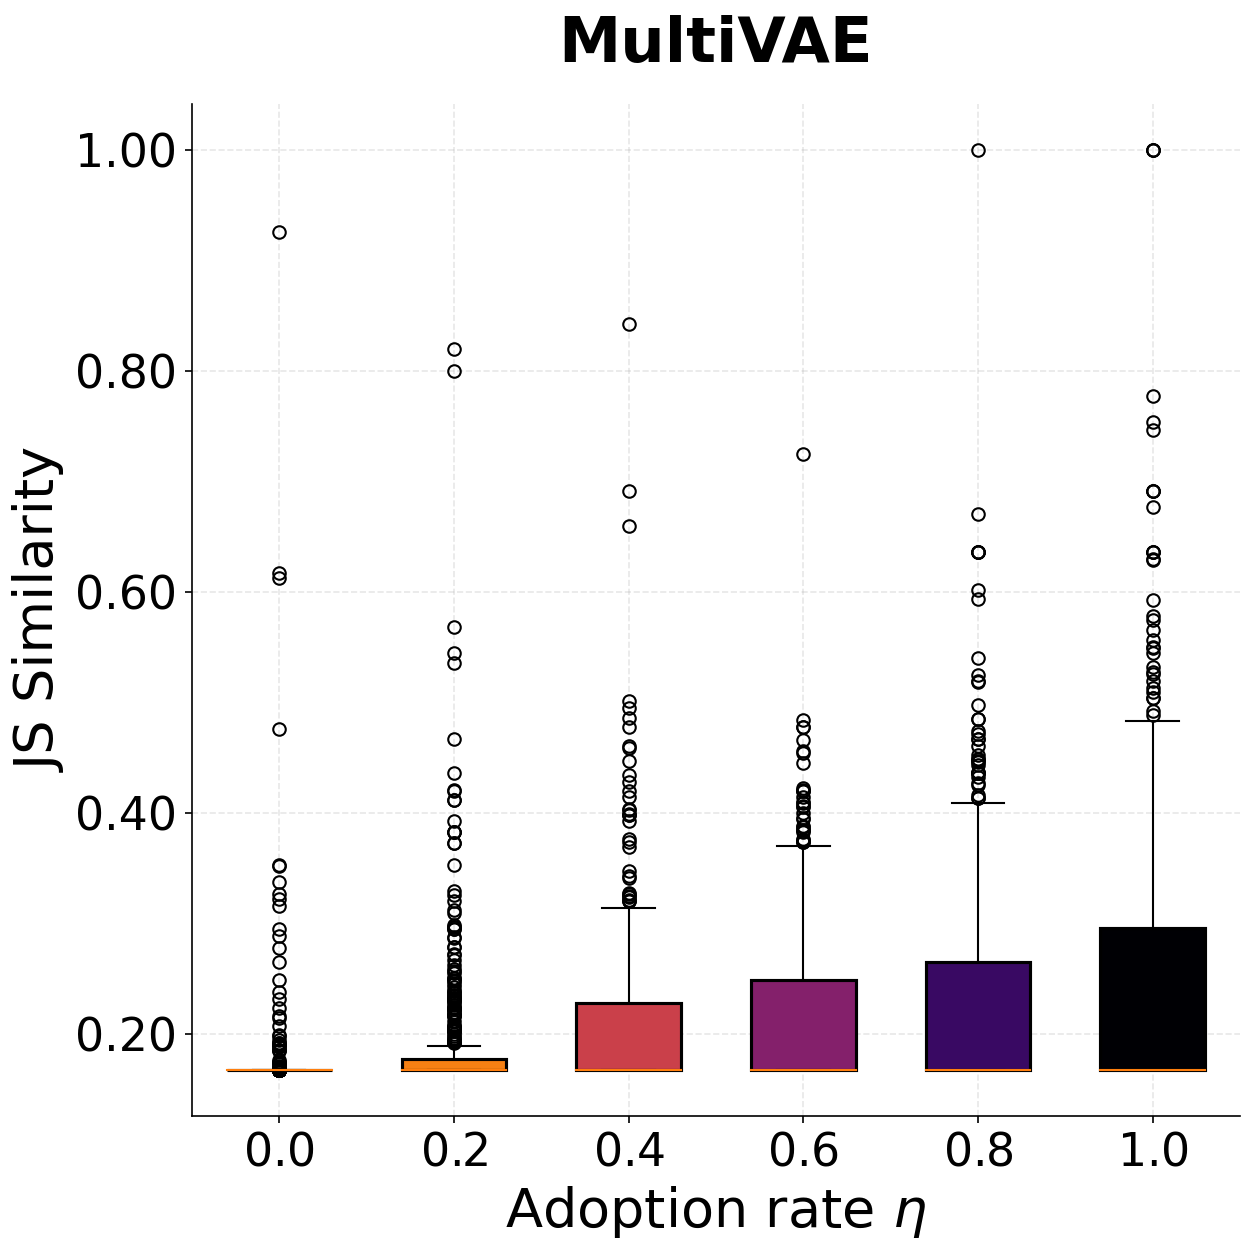

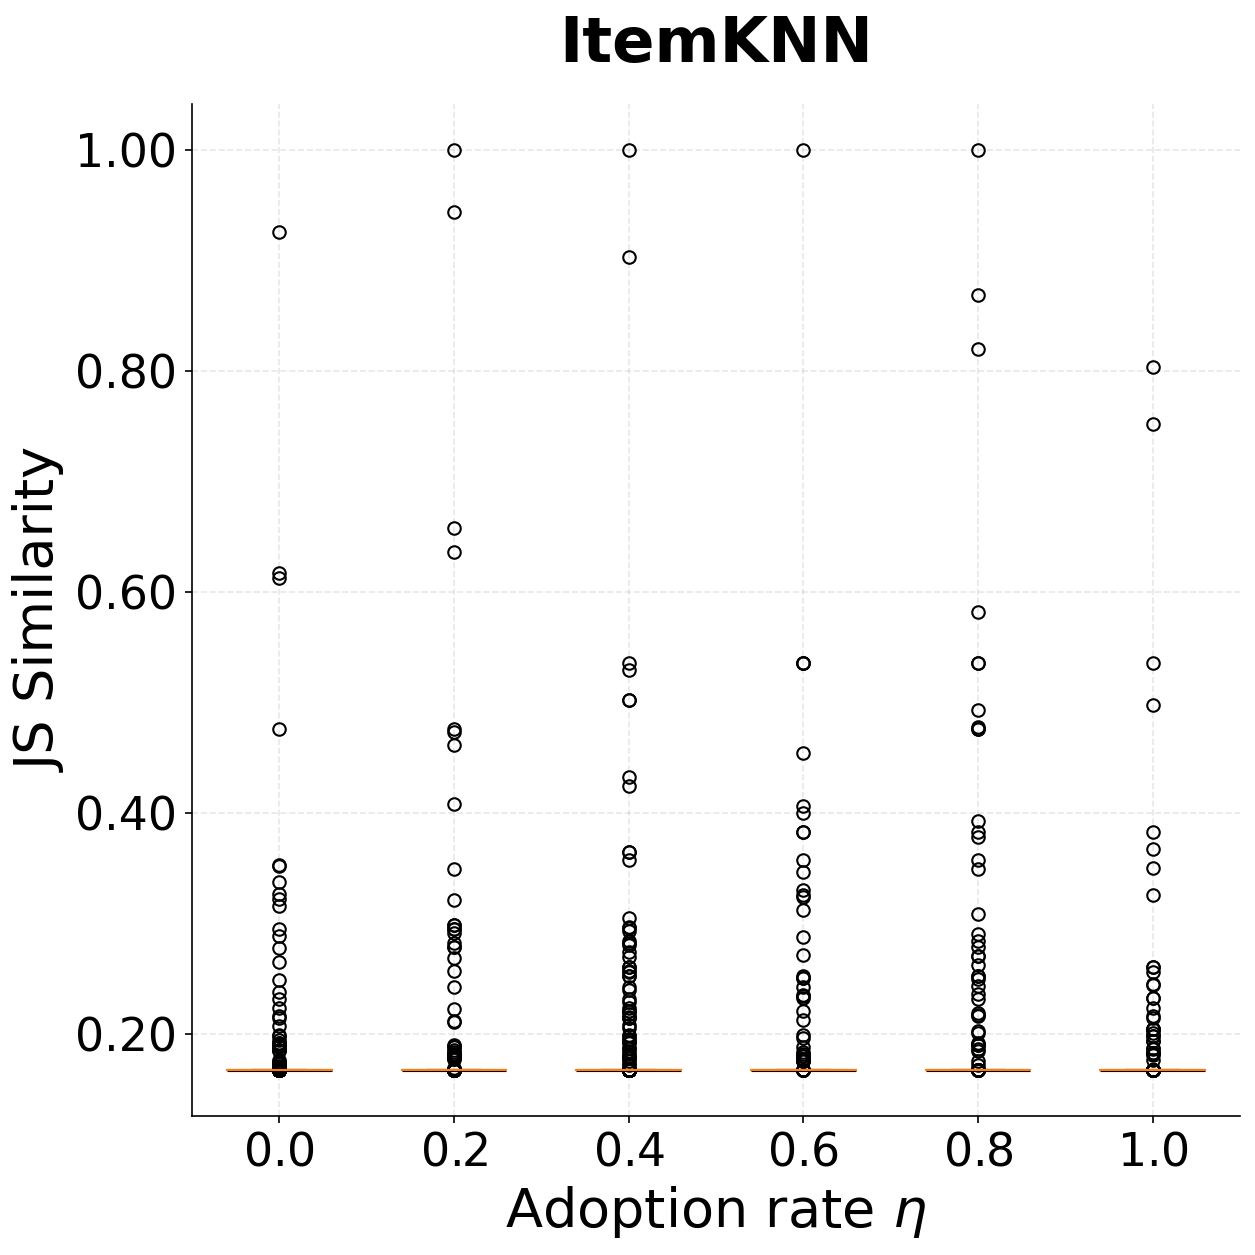

In [27]:
plot_boxplot_per_algorithm(
    jensen_shannon_distributions,
    ps,
    algorithms,
    save_path="figures/",
    metric_name="JS Similarity"
)